[*********************100%***********************]  1 of 1 completed

🚀 Inizializzazione Backtest Bear Market...
📊 Analisi periodo: 2007-2024
💶 Capitale iniziale: 10.000€
💶 PAC mensile: 500€

🐻 BACKTEST STRATEGIE BEAR MARKET
Scaricando dati per ^GSPC...
Dati scaricati: 4529 righe



📊 Bear Market identificati: 30
  • 2008-07-09 → 2008-07-10: -20.5%
  • 2008-07-11 → 2008-07-17: -22.4%
  • 2008-07-28 → 2008-07-29: -21.1%
  • 2008-08-04 → 2008-08-05: -20.2%
  • 2008-09-04 → 2008-09-08: -21.0%
  • 2008-09-09 → 2008-09-19: -26.1%
  • 2008-09-22 → 2010-12-21: -56.8%
  • 2011-08-04 → 2011-10-24: -29.8%
  • 2011-10-25 → 2011-10-27: -21.5%
  • 2011-11-01 → 2011-11-03: -22.2%
  • 2011-11-09 → 2011-11-11: -21.5%
  • 2011-11-14 → 2011-11-15: -20.0%
  • 2011-11-16 → 2011-12-05: -26.0%
  • 2011-12-08 → 2011-12-09: -21.1%
  • 2011-12-12 → 2011-12-22: -23.0%
  • 2011-12-28 → 2011-12-29: -20.2%
  • 2020-03-12 → 2020-03-13: -26.7%
  • 2020-03-16 → 2020-04-08: -33.9%
  • 2022-06-13 → 2022-06-24: -23.6%
  • 2022-06-28 → 2022-07-06: -21.1%
  • 2022-07-12 → 2022-07-15: -21.0%
  • 2022-07-18 → 2022-07-19: -20.1%
  • 2022-09-21 → 2022-10-25: -25.4%
  • 2022-10-26 → 2022-10-28: -20.6%
  • 2022-11-02 → 2022-11-10: -22.4%
  • 2022-12-19 → 2022-12-21: -20.4%
  • 2022-12-22 → 2022-12-23: -20

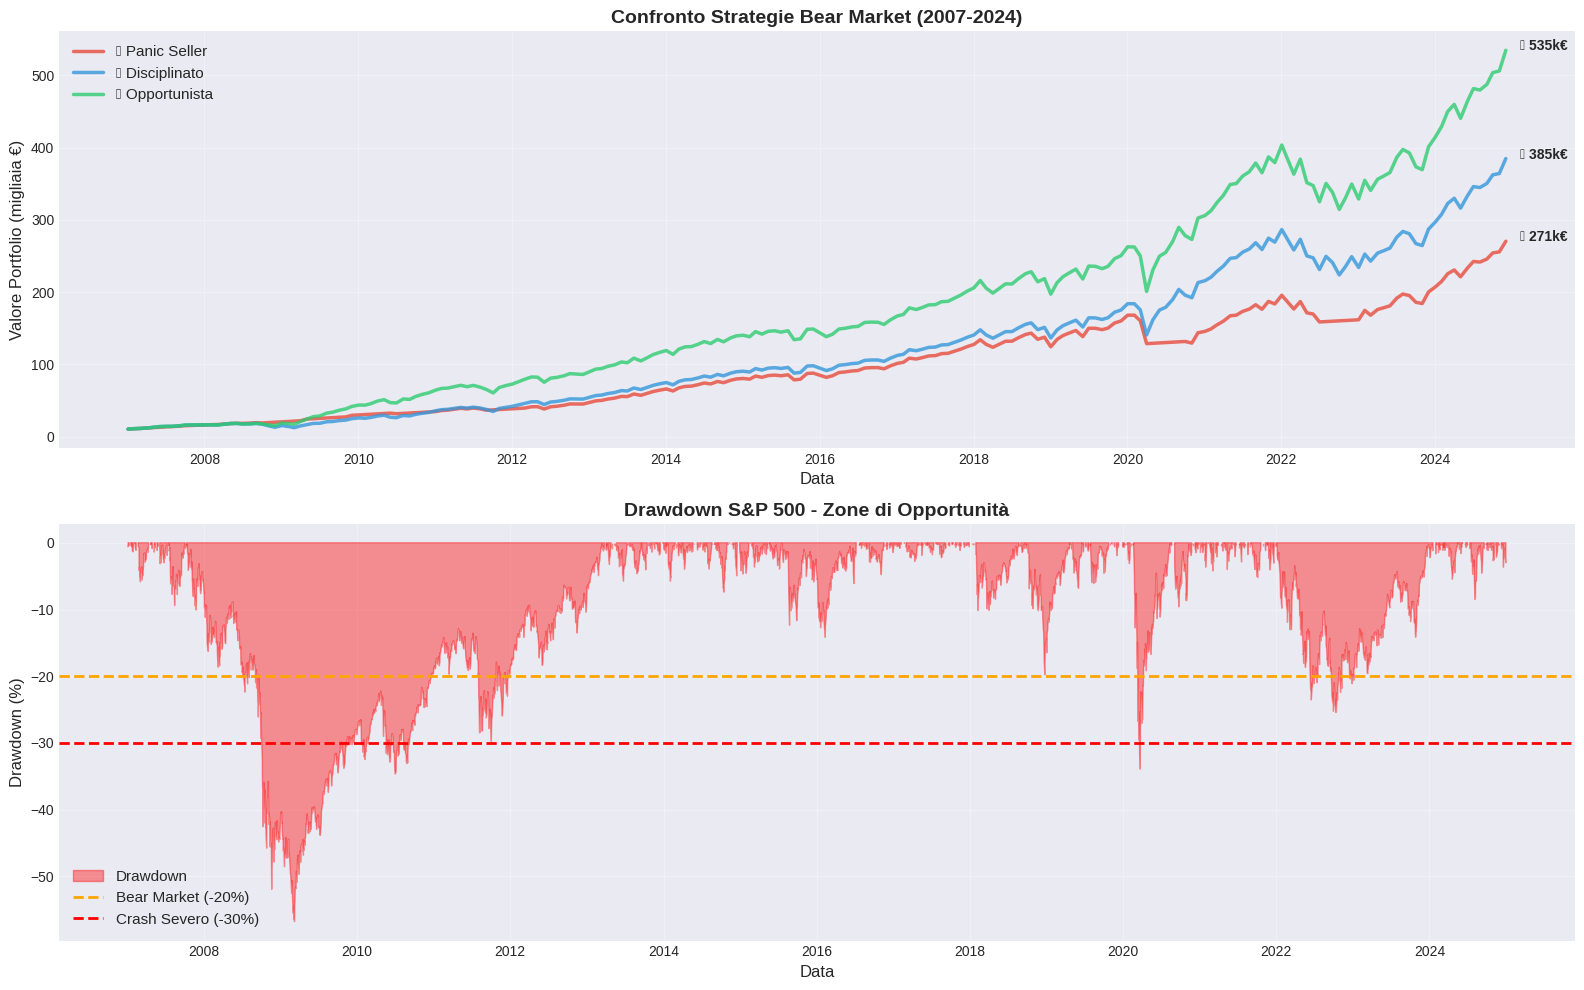





📊 ANALISI PROBABILISTICA: Rischio di Perdita per Orizzonte

Orizzonte Prob. Perdita Perdita Media Guadagno Medio
 1 giorno         46.3%         -0.7%           0.7%
   1 mese         38.2%         -3.3%           3.3%
   1 anno         25.9%        -11.4%          16.4%
   3 anni         14.7%        -17.1%          36.4%
   5 anni         16.2%        -11.2%          64.0%
  10 anni          7.0%        -14.9%         130.6%
  20 anni          0.0%          0.0%         340.8%


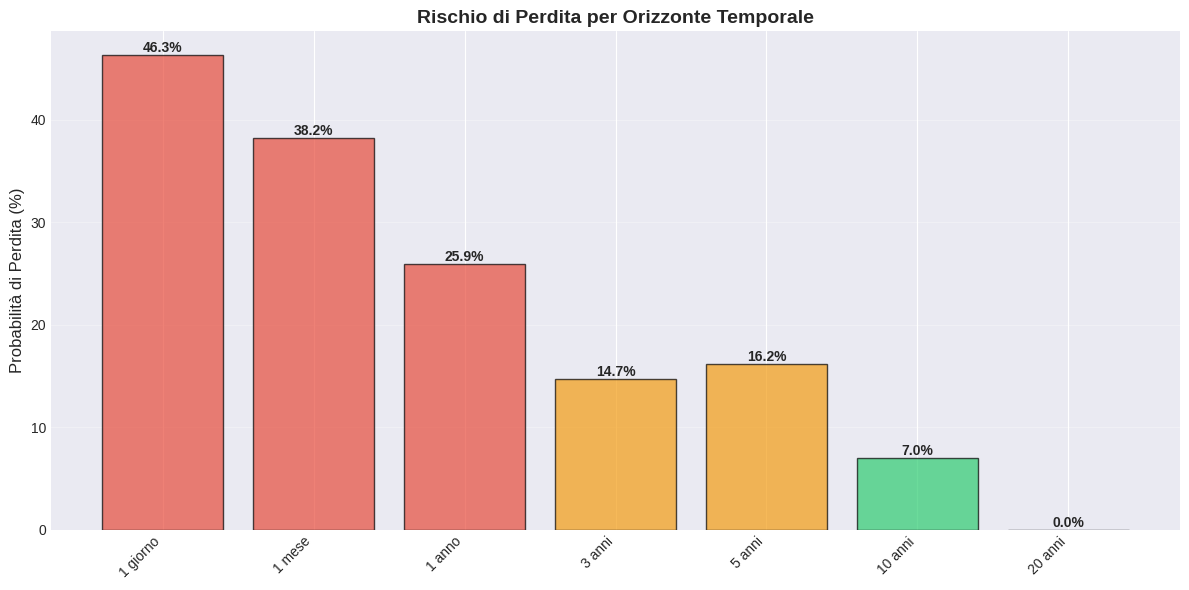


⏱️  ANALISI TEMPI DI RECUPERO POST BEAR MARKET

2007-2009 (Crisi Finanziaria):
  📉 Minimo: 2009-03-09
  📈 Recupero: 2013-03-28
  ⏱️  Tempo: 1480 giorni (49.3 mesi)

2020 (Covid):
  📉 Minimo: 2020-03-23
  📈 Recupero: 2020-08-18
  ⏱️  Tempo: 148 giorni (4.9 mesi)

2022 (Inflazione):
  📉 Minimo: 2022-10-12
  📈 Recupero: 2023-06-20
  ⏱️  Tempo: 251 giorni (8.4 mesi)

📊 Tempo medio di recupero: 626 giorni (20.9 mesi)

✅ BACKTEST COMPLETATO

📁 File generati:
  • bear_market_backtest.png (grafico confronto strategie)
  • Tutti i risultati visualizzati sopra

💡 Conclusione: Chi resta investito durante i bear market, VINCE.


In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Configurazione per Colab
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

class BearMarketBacktest:
    """
    Classe per backtesting strategie durante bear market
    Confronta 3 strategie:
    1. Panic Seller (vende a -20%, rientra dopo 6 mesi)
    2. Disciplinato (continua PAC normale)
    3. Opportunista (raddoppia PAC durante ribassi)
    """

    def __init__(self, ticker='^GSPC', start_date='2007-01-01', end_date='2024-12-31'):
        self.ticker = ticker
        self.start_date = start_date
        self.end_date = end_date
        self.data = None
        self.initial_capital = 10000
        self.monthly_investment = 500

    def download_data(self):
        """Scarica dati storici da Yahoo Finance"""
        print(f"Scaricando dati per {self.ticker}...")

        # Scarica dati con auto_adjust=False per avere Close separato da Adj Close
        raw_data = yf.download(self.ticker, start=self.start_date, end=self.end_date, auto_adjust=False)

        # Se il risultato è un DataFrame multicolonna (quando scarichi un ticker),
        # yfinance può restituire colonne multiple anche per un singolo ticker
        # Assicuriamoci di lavorare con un DataFrame pulito
        if isinstance(raw_data.columns, pd.MultiIndex):
            # Se abbiamo MultiIndex, appiattiscilo
            raw_data.columns = raw_data.columns.get_level_values(0)

        self.data = pd.DataFrame()
        self.data['Close'] = raw_data['Close'].squeeze()  # .squeeze() converte DataFrame a Series se necessario
        self.data['Returns'] = self.data['Close'].pct_change()

        print(f"Dati scaricati: {len(self.data)} righe")
        return self.data

    def detect_bear_markets(self, threshold=-0.20):
        """Identifica bear market (cali >20% dai massimi)"""
        # Calcola massimo cumulativo
        self.data['Cummax'] = self.data['Close'].cummax()

        # Calcola drawdown come Series (non DataFrame)
        close_series = self.data['Close'].squeeze()
        cummax_series = self.data['Cummax'].squeeze()
        self.data['Drawdown'] = (close_series - cummax_series) / cummax_series

        # Identifica bear market
        self.data['Bear_Market'] = self.data['Drawdown'] <= threshold

        # Trova inizio e fine bear market
        bear_markets = []
        in_bear = False
        start = None

        for date, row in self.data.iterrows():
            if row['Bear_Market'] and not in_bear:
                start = date
                in_bear = True
            elif not row['Bear_Market'] and in_bear:
                max_dd = self.data.loc[start:date, 'Drawdown'].min()
                bear_markets.append({
                    'start': start,
                    'end': date,
                    'max_drawdown': max_dd
                })
                in_bear = False

        return bear_markets

    def strategy_panic_seller(self):
        """
        Strategia 1: Lo Spaventato
        - Vende tutto quando mercato -20%
        - Aspetta 6 mesi dopo il minimo
        - Reinveste tutto
        """
        portfolio = []
        cash = self.initial_capital
        shares = 0
        is_sold = False
        sold_date = None
        reentry_date = None

        monthly_dates = pd.date_range(start=self.start_date, end=self.end_date, freq='MS')

        for date in monthly_dates:
            # Trova la data più vicina disponibile
            available_dates = self.data.index[self.data.index >= date]
            if len(available_dates) == 0:
                continue
            date = available_dates[0]

            price = self.data.loc[date, 'Close']
            drawdown = self.data.loc[date, 'Drawdown']

            # Logica vendita in panico
            if drawdown <= -0.20 and not is_sold and shares > 0:
                # VENDI TUTTO
                cash += shares * price
                shares = 0
                is_sold = True
                sold_date = date
                reentry_date = date + timedelta(days=180)  # 6 mesi dopo
                print(f"⚠️  PANIC SELL @ {date.strftime('%Y-%m-%d')}: Venduto tutto a {price:.2f}€ (Drawdown: {drawdown:.1%})")

            # Logica rientro
            if is_sold and date >= reentry_date:
                # Rientra nel mercato
                shares = cash / price
                cash = 0
                is_sold = False
                print(f"🔄 RE-ENTRY @ {date.strftime('%Y-%m-%d')}: Ricomprato a {price:.2f}€")

            # Investimento mensile (solo se non è venduto)
            if not is_sold:
                shares += self.monthly_investment / price
            else:
                cash += self.monthly_investment

            portfolio_value = (shares * price) + cash
            portfolio.append({
                'date': date,
                'portfolio_value': portfolio_value,
                'shares': shares,
                'cash': cash,
                'strategy': 'Panic Seller'
            })

        return pd.DataFrame(portfolio)

    def strategy_disciplined(self):
        """
        Strategia 2: Il Disciplinato
        - Continua PAC normale
        - Non vende mai
        - Ignora i ribassi
        """
        portfolio = []
        first_price = self.data.iloc[0]['Close']
        shares = self.initial_capital / first_price

        monthly_dates = pd.date_range(start=self.start_date, end=self.end_date, freq='MS')

        for date in monthly_dates:
            # Trova la data più vicina disponibile
            available_dates = self.data.index[self.data.index >= date]
            if len(available_dates) == 0:
                continue
            date = available_dates[0]

            price = self.data.loc[date, 'Close']

            # Investimento mensile costante
            shares += self.monthly_investment / price

            portfolio_value = shares * price
            portfolio.append({
                'date': date,
                'portfolio_value': portfolio_value,
                'shares': shares,
                'cash': 0,
                'strategy': 'Disciplinato'
            })

        return pd.DataFrame(portfolio)

    def strategy_opportunist(self):
        """
        Strategia 3: L'Opportunista
        - Continua PAC normale
        - Raddoppia investimento quando mercato -20%
        - Triplica quando mercato -30%
        """
        portfolio = []
        first_price = self.data.iloc[0]['Close']
        shares = self.initial_capital / first_price

        monthly_dates = pd.date_range(start=self.start_date, end=self.end_date, freq='MS')

        for date in monthly_dates:
            # Trova la data più vicina disponibile
            available_dates = self.data.index[self.data.index >= date]
            if len(available_dates) == 0:
                continue
            date = available_dates[0]

            price = self.data.loc[date, 'Close']
            drawdown = self.data.loc[date, 'Drawdown']

            # Calcola investimento mensile (aumenta durante ribassi)
            if drawdown <= -0.30:
                monthly_inv = self.monthly_investment * 3  # Triplo
                print(f"💰 OPPORTUNITY @ {date.strftime('%Y-%m-%d')}: Investimento TRIPLICATO (Drawdown: {drawdown:.1%})")
            elif drawdown <= -0.20:
                monthly_inv = self.monthly_investment * 2  # Doppio
                print(f"💰 OPPORTUNITY @ {date.strftime('%Y-%m-%d')}: Investimento RADDOPPIATO (Drawdown: {drawdown:.1%})")
            else:
                monthly_inv = self.monthly_investment

            shares += monthly_inv / price

            portfolio_value = shares * price
            portfolio.append({
                'date': date,
                'portfolio_value': portfolio_value,
                'shares': shares,
                'cash': 0,
                'strategy': 'Opportunista'
            })

        return pd.DataFrame(portfolio)

    def run_all_strategies(self):
        """Esegue tutte e 3 le strategie e confronta"""
        print("\n" + "="*70)
        print("🐻 BACKTEST STRATEGIE BEAR MARKET")
        print("="*70)

        # Scarica dati
        self.download_data()

        # Identifica bear market
        bear_markets = self.detect_bear_markets()
        print(f"\n📊 Bear Market identificati: {len(bear_markets)}")
        for bm in bear_markets:
            print(f"  • {bm['start'].strftime('%Y-%m-%d')} → {bm['end'].strftime('%Y-%m-%d')}: {bm['max_drawdown']:.1%}")

        print("\n" + "-"*70)
        print("⚙️  ESECUZIONE STRATEGIE...")
        print("-"*70)

        # Esegui strategie
        df_panic = self.strategy_panic_seller()
        print("\n✅ Strategia 1 completata")

        df_disciplined = self.strategy_disciplined()
        print("✅ Strategia 2 completata")

        df_opportunist = self.strategy_opportunist()
        print("✅ Strategia 3 completata")

        # Risultati finali
        print("\n" + "="*70)
        print("📈 RISULTATI FINALI")
        print("="*70)

        final_panic = df_panic.iloc[-1]['portfolio_value']
        final_disciplined = df_disciplined.iloc[-1]['portfolio_value']
        final_opportunist = df_opportunist.iloc[-1]['portfolio_value']

        total_invested = self.initial_capital + (self.monthly_investment * len(df_disciplined))

        print(f"\n💶 Capitale iniziale: {self.initial_capital:,.0f}€")
        print(f"💶 Investimenti mensili: {self.monthly_investment}€ x {len(df_disciplined)} mesi")
        print(f"💶 Totale investito: {total_invested:,.0f}€")

        print(f"\n❌ STRATEGIA 1 - Lo Spaventato (Panic Seller):")
        print(f"   Valore finale: {final_panic:,.0f}€")
        print(f"   Rendimento: {((final_panic/total_invested)-1)*100:+.1f}%")
        print(f"   CAGR: {self.calculate_cagr(total_invested, final_panic, len(df_panic)/12):.2f}%")

        print(f"\n✅ STRATEGIA 2 - Il Disciplinato (PAC Costante):")
        print(f"   Valore finale: {final_disciplined:,.0f}€")
        print(f"   Rendimento: {((final_disciplined/total_invested)-1)*100:+.1f}%")
        print(f"   CAGR: {self.calculate_cagr(total_invested, final_disciplined, len(df_disciplined)/12):.2f}%")

        print(f"\n🚀 STRATEGIA 3 - L'Opportunista (PAC + Extra su Ribassi):")
        print(f"   Valore finale: {final_opportunist:,.0f}€")
        print(f"   Rendimento: {((final_opportunist/total_invested)-1)*100:+.1f}%")
        print(f"   CAGR: {self.calculate_cagr(total_invested, final_opportunist, len(df_opportunist)/12):.2f}%")

        print(f"\n" + "="*70)
        print("💡 CONFRONTO STRATEGIE")
        print("="*70)
        print(f"Differenza Disciplinato vs Panic Seller: +{final_disciplined - final_panic:,.0f}€")
        print(f"Differenza Opportunista vs Panic Seller: +{final_opportunist - final_panic:,.0f}€")
        print(f"Differenza Opportunista vs Disciplinato: +{final_opportunist - final_disciplined:,.0f}€")

        print(f"\n💸 COSTO DEL PANIC SELLING: {final_disciplined - final_panic:,.0f}€")
        print(f"💸 VANTAGGIO OPPORTUNISMO: +{final_opportunist - final_disciplined:,.0f}€")

        # Visualizza grafici
        self.plot_comparison(df_panic, df_disciplined, df_opportunist)

        return df_panic, df_disciplined, df_opportunist

    def calculate_cagr(self, start_value, end_value, years):
        """Calcola Compound Annual Growth Rate"""
        if years <= 0:
            return 0
        return (((end_value / start_value) ** (1 / years)) - 1) * 100

    def plot_comparison(self, df_panic, df_disciplined, df_opportunist):
        """Crea grafici di confronto"""
        fig = plt.figure(figsize=(16, 10))

        # Grafico 1: Evoluzione portfolio
        ax1 = plt.subplot(2, 1, 1)
        ax1.plot(df_panic['date'], df_panic['portfolio_value']/1000,
                label='❌ Panic Seller', linewidth=2.5, color='#e74c3c', alpha=0.8)
        ax1.plot(df_disciplined['date'], df_disciplined['portfolio_value']/1000,
                label='✅ Disciplinato', linewidth=2.5, color='#3498db', alpha=0.8)
        ax1.plot(df_opportunist['date'], df_opportunist['portfolio_value']/1000,
                label='🚀 Opportunista', linewidth=2.5, color='#2ecc71', alpha=0.8)

        ax1.set_xlabel('Data', fontsize=12)
        ax1.set_ylabel('Valore Portfolio (migliaia €)', fontsize=12)
        ax1.set_title('Confronto Strategie Bear Market (2007-2024)', fontsize=14, fontweight='bold')
        ax1.legend(fontsize=11, loc='upper left')
        ax1.grid(True, alpha=0.3)

        # Annotazioni finali
        final_values = [
            (df_panic.iloc[-1]['date'], df_panic.iloc[-1]['portfolio_value']/1000, '❌'),
            (df_disciplined.iloc[-1]['date'], df_disciplined.iloc[-1]['portfolio_value']/1000, '✅'),
            (df_opportunist.iloc[-1]['date'], df_opportunist.iloc[-1]['portfolio_value']/1000, '🚀')
        ]
        for date, value, emoji in final_values:
            ax1.annotate(f'{emoji} {value:.0f}k€',
                        xy=(date, value),
                        xytext=(10, 0),
                        textcoords='offset points',
                        fontsize=10,
                        fontweight='bold')

        # Grafico 2: Drawdown S&P 500
        ax2 = plt.subplot(2, 1, 2)
        ax2.fill_between(self.data.index, self.data['Drawdown']*100, 0,
                         where=self.data['Drawdown']<0, alpha=0.4, color='red', label='Drawdown')
        ax2.axhline(y=-20, color='orange', linestyle='--', linewidth=2, label='Bear Market (-20%)')
        ax2.axhline(y=-30, color='red', linestyle='--', linewidth=2, label='Crash Severo (-30%)')

        ax2.set_xlabel('Data', fontsize=12)
        ax2.set_ylabel('Drawdown (%)', fontsize=12)
        ax2.set_title('Drawdown S&P 500 - Zone di Opportunità', fontsize=14, fontweight='bold')
        ax2.legend(fontsize=11)
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('bear_market_backtest.png', dpi=300, bbox_inches='tight')
        print("\n📊 Grafico salvato come 'bear_market_backtest.png'")
        plt.show()

# Analisi aggiuntive
class BearMarketAnalysis:
    """Analisi probabilistiche e statistiche"""

    @staticmethod
    def probability_loss_by_timeframe(ticker='^GSPC', start_date='1950-01-01'):
        """
        Calcola probabilità di perdita per diversi orizzonti temporali
        """
        print("\n" + "="*70)
        print("📊 ANALISI PROBABILISTICA: Rischio di Perdita per Orizzonte")
        print("="*70)

        data = yf.download(ticker, start=start_date, end='2024-12-31', auto_adjust=False, progress=False)
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)

        close_prices = data['Close'].squeeze()

        timeframes = {
            '1 giorno': 1,
            '1 mese': 21,
            '1 anno': 252,
            '3 anni': 252*3,
            '5 anni': 252*5,
            '10 anni': 252*10,
            '20 anni': 252*20
        }

        results = []

        for name, days in timeframes.items():
            if days > len(close_prices):
                continue

            returns = []
            for i in range(len(close_prices) - days):
                ret = (close_prices.iloc[i+days] / close_prices.iloc[i]) - 1
                returns.append(ret)

            returns = np.array(returns)
            prob_loss = (returns < 0).sum() / len(returns)
            avg_loss = returns[returns < 0].mean() if (returns < 0).any() else 0
            avg_gain = returns[returns > 0].mean() if (returns > 0).any() else 0

            results.append({
                'Orizzonte': name,
                'Prob. Perdita': f"{prob_loss*100:.1f}%",
                'Perdita Media': f"{avg_loss*100:.1f}%",
                'Guadagno Medio': f"{avg_gain*100:.1f}%"
            })

        df = pd.DataFrame(results)
        print("\n" + df.to_string(index=False))

        # Visualizza graficamente
        fig, ax = plt.subplots(figsize=(12, 6))

        orizzonti = [r['Orizzonte'] for r in results]
        prob_perdite = [float(r['Prob. Perdita'].strip('%')) for r in results]

        colors = ['#e74c3c' if p > 20 else '#f39c12' if p > 10 else '#2ecc71' for p in prob_perdite]

        bars = ax.bar(orizzonti, prob_perdite, color=colors, alpha=0.7, edgecolor='black')
        ax.set_ylabel('Probabilità di Perdita (%)', fontsize=12)
        ax.set_title('Rischio di Perdita per Orizzonte Temporale', fontsize=14, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)

        # Annotazioni
        for bar, prob in zip(bars, prob_perdite):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{prob:.1f}%',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')

        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

        return df

    @staticmethod
    def recovery_time_analysis(ticker='^GSPC'):
        """Analizza tempi di recupero dopo bear market"""
        print("\n" + "="*70)
        print("⏱️  ANALISI TEMPI DI RECUPERO POST BEAR MARKET")
        print("="*70)

        # Bear market storici noti
        bear_markets = [
            {'name': '2007-2009 (Crisi Finanziaria)', 'bottom': '2009-03-09', 'recovery': '2013-03-28'},
            {'name': '2020 (Covid)', 'bottom': '2020-03-23', 'recovery': '2020-08-18'},
            {'name': '2022 (Inflazione)', 'bottom': '2022-10-12', 'recovery': '2023-06-20'},
        ]

        results = []

        for bm in bear_markets:
            bottom_date = pd.to_datetime(bm['bottom'])
            recovery_date = pd.to_datetime(bm['recovery'])
            days = (recovery_date - bottom_date).days
            months = days / 30

            print(f"\n{bm['name']}:")
            print(f"  📉 Minimo: {bm['bottom']}")
            print(f"  📈 Recupero: {bm['recovery']}")
            print(f"  ⏱️  Tempo: {days} giorni ({months:.1f} mesi)")

            results.append({
                'Bear Market': bm['name'],
                'Giorni': days,
                'Mesi': f"{months:.1f}"
            })

        # Media
        avg_days = sum([r['Giorni'] for r in results]) / len(results)
        print(f"\n📊 Tempo medio di recupero: {avg_days:.0f} giorni ({avg_days/30:.1f} mesi)")

        return pd.DataFrame(results)

# ESECUZIONE PRINCIPALE
print("🚀 Inizializzazione Backtest Bear Market...")
print("📊 Analisi periodo: 2007-2024")
print("💶 Capitale iniziale: 10.000€")
print("💶 PAC mensile: 500€")

# Backtest strategie
backtest = BearMarketBacktest(
    ticker='^GSPC',  # S&P 500
    start_date='2007-01-01',
    end_date='2024-12-31'
)

df_panic, df_disciplined, df_opportunist = backtest.run_all_strategies()

# Analisi probabilistiche
print("\n\n")
analysis = BearMarketAnalysis()
prob_df = analysis.probability_loss_by_timeframe()
recovery_df = analysis.recovery_time_analysis()

print("\n" + "="*70)
print("✅ BACKTEST COMPLETATO")
print("="*70)
print("\n📁 File generati:")
print("  • bear_market_backtest.png (grafico confronto strategie)")
print("  • Tutti i risultati visualizzati sopra")
print("\n💡 Conclusione: Chi resta investito durante i bear market, VINCE.")